# Tesla Stock Price Prediction using SimpleRNN and LSTM

## Domain
Financial Services

## Problem Statement
Predict Tesla stock closing prices using SimpleRNN and LSTM models and compare their performance.

## Project Objectives
- Analyze Tesla stock price data.
- Build SimpleRNN model.
- Build LSTM model.
- Predict stock prices for 1-day, 5-days and 10-days.
- Compare both models.



# Section 1: Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, SimpleRNN, LSTM
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

plt.style.use('seaborn-v0_8-darkgrid')
tf.random.set_seed(42)
np.random.seed(42)

print("All libraries imported successfully")


All libraries imported successfully


# Section 2: Load Dataset

In [2]:
df = pd.read_csv("TSLA.csv")
print("Dataset loaded successfully")
df.head()


Dataset loaded successfully


,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
1,2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2,2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
3,2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
4,2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


In [3]:
df.tail()

,Date,Open,High,Low,Close,Adj Close,Volume
2411,2020-01-28,568.489990,576.809998,558.080017,566.900024,566.900024,11788500
2412,2020-01-29,575.690002,589.799988,567.429993,580.989990,580.989990,17801500
2413,2020-01-30,632.419983,650.880005,618.000000,640.809998,640.809998,29005700
2414,2020-01-31,640.000000,653.000000,632.520020,650.570007,650.570007,15719300
2415,2020-02-03,673.690002,786.140015,673.520020,780.000000,780.000000,47065000


# Section 3: Data Understanding

In [4]:
print("Dataset Shape:", df.shape)
df.info()


Dataset Shape: (2416, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2416 entries, 0 to 2415
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2416 non-null   object 
 1   Open       2416 non-null   float64
 2   High       2416 non-null   float64
 3   Low        2416 non-null   float64
 4   Close      2416 non-null   float64
 5   Adj Close  2416 non-null   float64
 6   Volume     2416 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 132.3+ KB


In [5]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,2416.000000,2416.000000,2416.000000,2416.000000,2416.000000,2.416000e+03
mean,186.271147,189.578224,182.916639,186.403651,186.403651,5.572722e+06
std,118.740163,120.892329,116.857591,119.136020,119.136020,4.987809e+06
min,16.139999,16.629999,14.980000,15.800000,15.800000,1.185000e+05
25%,34.342498,34.897501,33.587501,34.400002,34.400002,1.899275e+06
50%,213.035004,216.745002,208.870002,212.960007,212.960007,4.578400e+06
75%,266.450012,270.927513,262.102501,266.774994,266.774994,7.361150e+06
max,673.690002,786.140015,673.520020,780.000000,780.000000,4.706500e+07


## Section 4: Data Cleaning

In [6]:
print("Missing Values:\n", df.isnull().sum())
print("\nDuplicate Records:", df.duplicated().sum())


Missing Values:
 Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Duplicate Records: 0


In [7]:
# Demonstrate the missing-value strategy on a simulated copy (real data has no gaps)
rng = np.random.RandomState(42)
demo = df.copy()
sim_idx = rng.choice(demo.index[20:-20], size=15, replace=False)
demo.loc[sim_idx, 'Adj Close'] = np.nan
print("Simulated NaNs:", demo['Adj Close'].isnull().sum())

demo['Adj Close'] = demo['Adj Close'].ffill().interpolate(method='linear')
print("After ffill + interpolate:", demo['Adj Close'].isnull().sum())


Simulated NaNs: 15
After ffill + interpolate: 0


In [8]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)
print(df["Date"].dtype)


datetime64[ns]


In [9]:
df.set_index("Date", inplace=True)
df.head()


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


## Section 5: Exploratory Data Analysis (EDA)

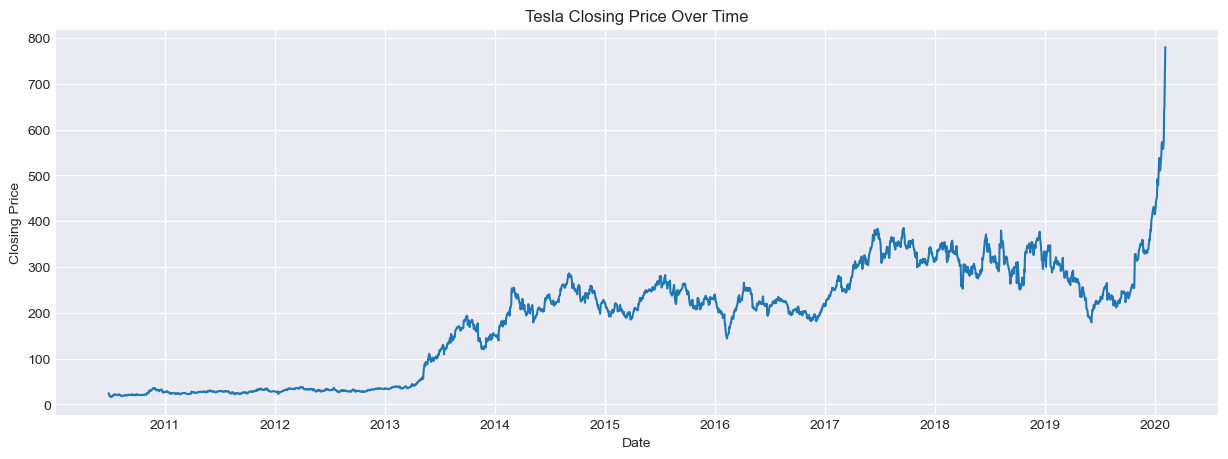

In [10]:
plt.figure(figsize=(15,5))
plt.plot(df["Close"])
plt.title("Tesla Closing Price Over Time")
plt.xlabel("Date"); plt.ylabel("Closing Price"); plt.grid(True)
plt.show()


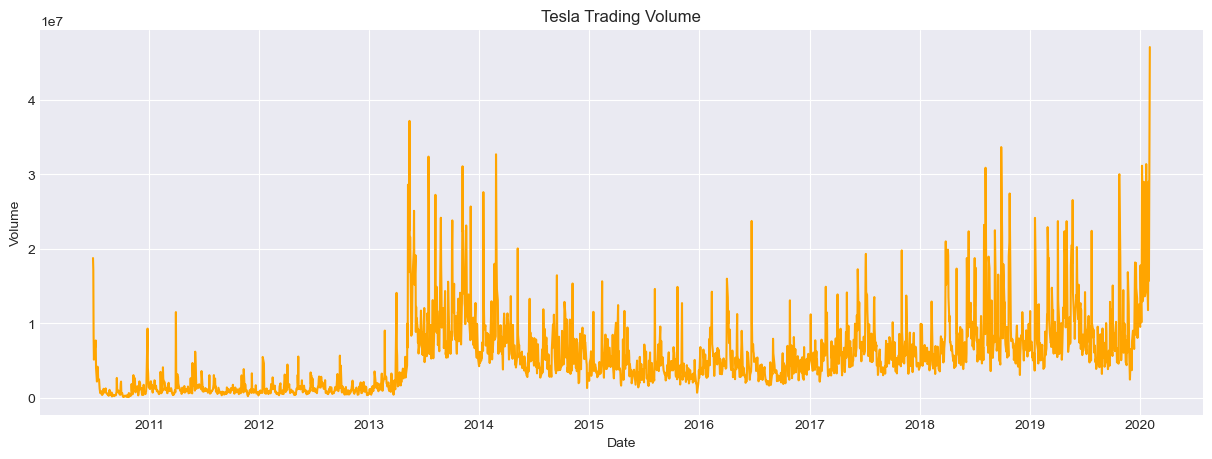

In [11]:
plt.figure(figsize=(15,5))
plt.plot(df["Volume"], color="orange")
plt.title("Tesla Trading Volume")
plt.xlabel("Date"); plt.ylabel("Volume"); plt.grid(True)
plt.show()


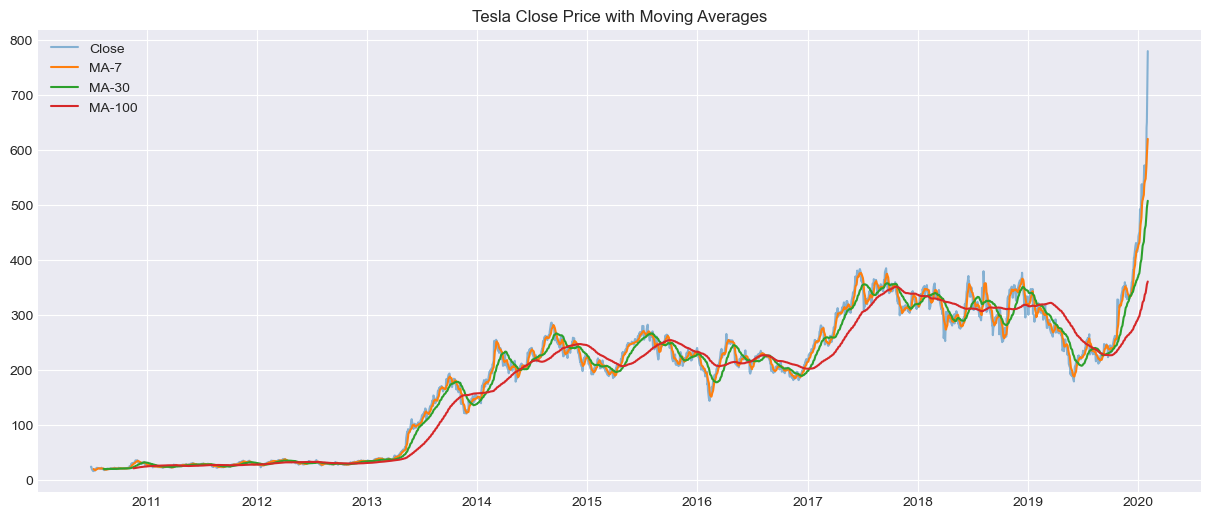

In [12]:
df["MA7"] = df["Close"].rolling(7).mean()
df["MA30"] = df["Close"].rolling(30).mean()
df["MA100"] = df["Close"].rolling(100).mean()

plt.figure(figsize=(15,6))
plt.plot(df["Close"], label="Close", alpha=0.5)
plt.plot(df["MA7"], label="MA-7")
plt.plot(df["MA30"], label="MA-30")
plt.plot(df["MA100"], label="MA-100")
plt.title("Tesla Close Price with Moving Averages")
plt.legend(); plt.show()


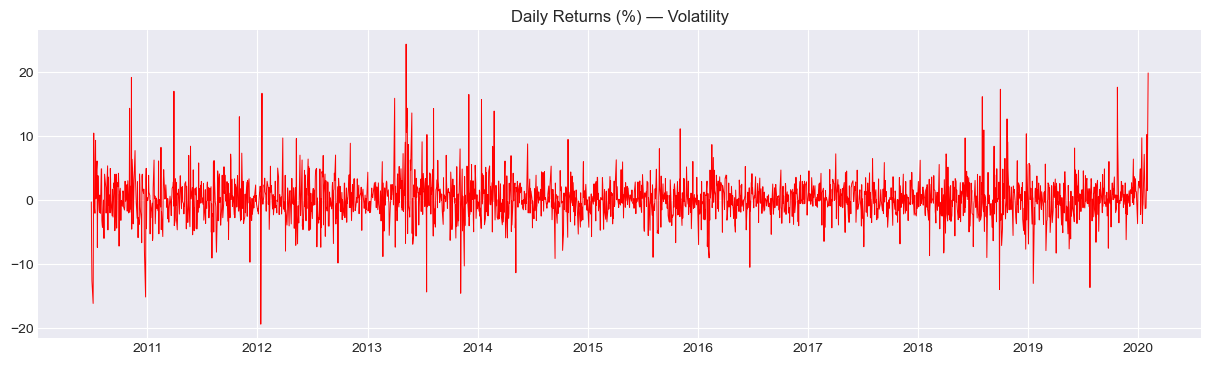

In [13]:
df["Daily_Return"] = df["Close"].pct_change() * 100
plt.figure(figsize=(15,4))
plt.plot(df["Daily_Return"], color="red", linewidth=0.7)
plt.title("Daily Returns (%) — Volatility")
plt.show()


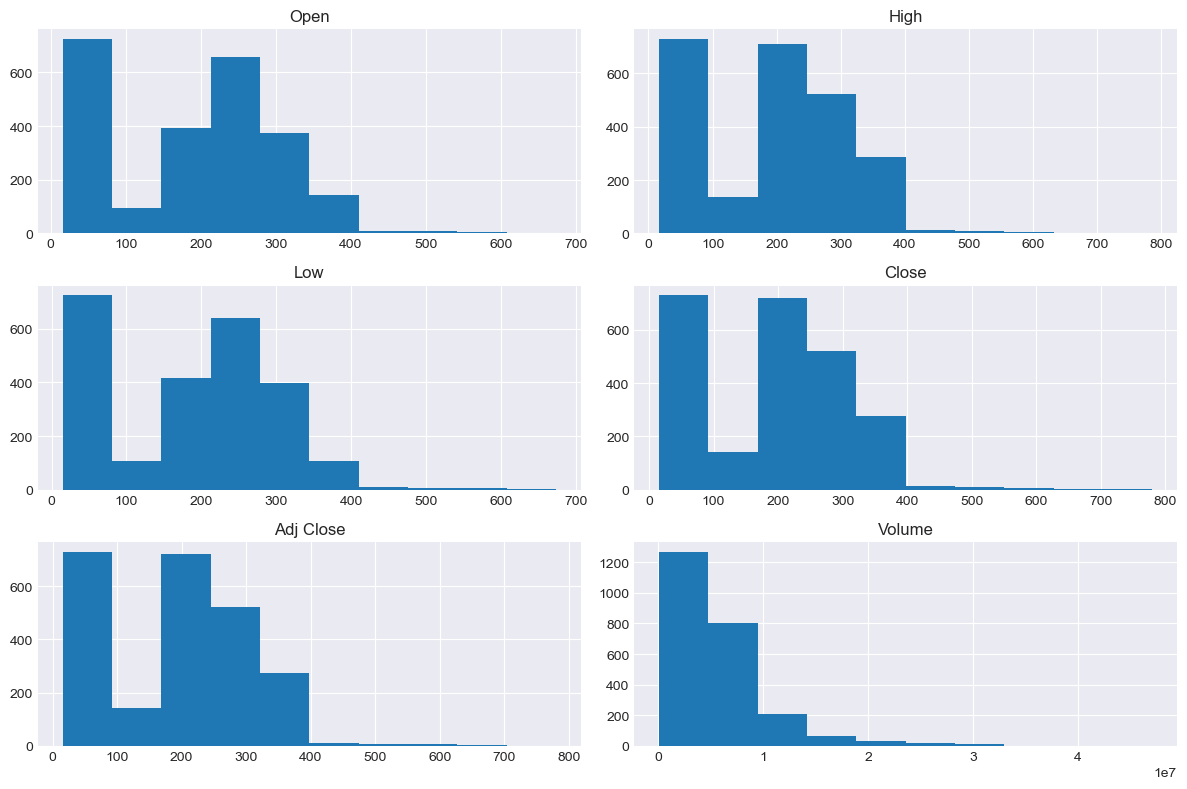

In [14]:
df[["Open","High","Low","Close","Adj Close","Volume"]].hist(figsize=(12,8))
plt.tight_layout(); plt.show()


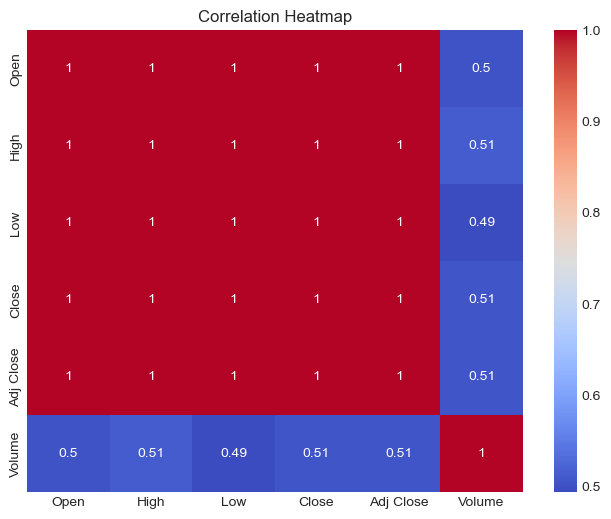

In [15]:
plt.figure(figsize=(8,6))
sns.heatmap(df[["Open","High","Low","Close","Adj Close","Volume"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


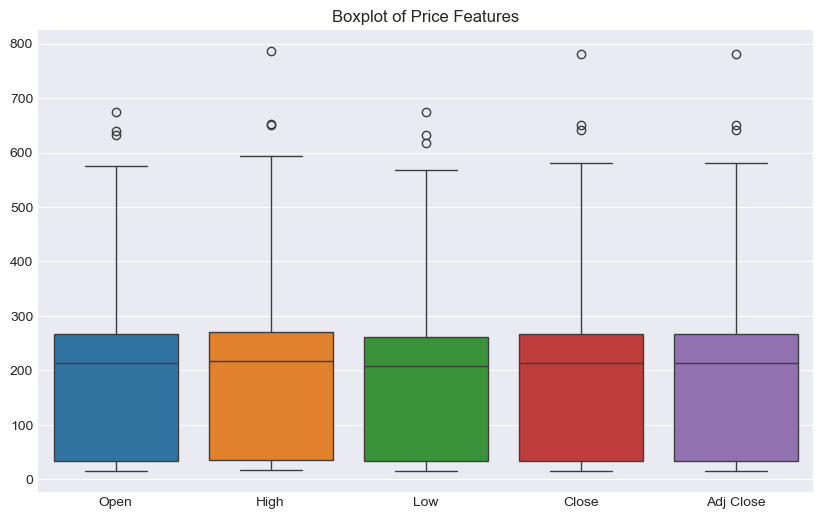

In [16]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df[["Open","High","Low","Close","Adj Close"]])
plt.title("Boxplot of Price Features")
plt.show()


# Section 6: Feature Engineering & Target Selection

In [17]:
data = df[["Adj Close"]]
print("Shape of selected data:", data.shape)
data.head()


Shape of selected data: (2416, 1)


,Adj Close
Date,
2010-06-29,23.889999
2010-06-30,23.830000
2010-07-01,21.959999
2010-07-02,19.200001
2010-07-06,16.110001


## Section 7: Data Scaling

In [18]:
SPLIT_RATIO = 0.8
split_point = int(len(data) * SPLIT_RATIO)
print("Split date:", df.index[split_point].date())

train_raw = data.values[:split_point]
test_raw  = data.values[split_point:]

scaler = MinMaxScaler(feature_range=(0,1))
scaler.fit(train_raw)                      # fit on TRAIN ONLY
train_scaled = scaler.transform(train_raw)
test_scaled  = scaler.transform(test_raw)

print("Train size:", len(train_raw), " Test size:", len(test_raw))


Split date: 2018-03-02
Train size: 1932  Test size: 484


## Section 8: Time-Series Sequence Creation (per forecast horizon)

In [19]:
WINDOW = 60
HORIZONS = [1, 5, 10]

def create_sequences(scaled_series, window, horizon):
    X, y = [], []
    for i in range(len(scaled_series) - window - horizon + 1):
        X.append(scaled_series[i:i+window, 0])
        y.append(scaled_series[i+window+horizon-1, 0])
    X = np.array(X); y = np.array(y)
    return X.reshape(X.shape[0], X.shape[1], 1), y

full_scaled = np.concatenate([train_scaled, test_scaled], axis=0)

datasets = {}
for h in HORIZONS:
    X_all, y_all = create_sequences(full_scaled, WINDOW, h)
    n_test = max(len(test_scaled) - h + 1, 1)
    X_train, y_train = X_all[:-n_test], y_all[:-n_test]
    X_test,  y_test  = X_all[-n_test:], y_all[-n_test:]
    datasets[h] = dict(X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test)
    print(f"Horizon {h}d -> X_train {X_train.shape}, X_test {X_test.shape}")


Horizon 1d -> X_train (1872, 60, 1), X_test (484, 60, 1)
Horizon 5d -> X_train (1872, 60, 1), X_test (480, 60, 1)
Horizon 10d -> X_train (1872, 60, 1), X_test (475, 60, 1)


## Section 9: Train-Test Split 

In [20]:
summary = pd.DataFrame([
    {"Horizon": h, "X_train": str(datasets[h]['X_train'].shape),
     "X_test": str(datasets[h]['X_test'].shape)} for h in HORIZONS
])
summary


,Horizon,X_train,X_test
0,1,"(1872, 60, 1)","(484, 60, 1)"
1,5,"(1872, 60, 1)","(480, 60, 1)"
2,10,"(1872, 60, 1)","(475, 60, 1)"


## Section 10: Model Architectures — SimpleRNN & LSTM

In [21]:
def build_simplernn(window=WINDOW, units=64, dropout=0.2, learning_rate=0.001):
    model = Sequential([
        SimpleRNN(units, return_sequences=True, input_shape=(window, 1)),
        Dropout(dropout),
        SimpleRNN(max(units//2, 8)),
        Dropout(dropout),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss="mean_squared_error")
    return model

def build_lstm(window=WINDOW, units=64, dropout=0.2, learning_rate=0.001):
    model = Sequential([
        LSTM(units, return_sequences=True, input_shape=(window, 1)),
        Dropout(dropout),
        LSTM(max(units//2, 8)),
        Dropout(dropout),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss="mean_squared_error")
    return model

build_simplernn().summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)               │ (None, 60, 64)              │           4,224 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 60, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_1 (SimpleRNN)             │ (None, 32)                  │           3,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,361 (28.75 KB)

 Trainable params: 7,361 (28.75 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
build_lstm().summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 60, 64)              │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 60, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

## Section 11: Training — SimpleRNN & LSTM for all 3 horizons

In [23]:
results = {}
histories = {}

for h in HORIZONS:
    Xtr, ytr = datasets[h]['X_train'], datasets[h]['y_train']
    Xte, yte = datasets[h]['X_test'], datasets[h]['y_test']

    for arch, builder in [("SimpleRNN", build_simplernn), ("LSTM", build_lstm)]:
        print(f"\n{'='*55}\nTraining {arch} | horizon={h}d\n{'='*55}")
        model = builder(WINDOW)
        ckpt = f"best_{arch}_h{h}.keras"
        cbs = [
            EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
            ModelCheckpoint(ckpt, monitor="val_loss", save_best_only=True)
        ]
        hist = model.fit(Xtr, ytr, validation_split=0.1, epochs=50,
                          batch_size=32, callbacks=cbs, verbose=0)
        test_mse_scaled = model.evaluate(Xte, yte, verbose=0)
        print(f"{arch} h={h}d -> epochs run: {len(hist.history['loss'])}, "
              f"final val_loss: {hist.history['val_loss'][-1]:.6f}, "
              f"test loss (scaled): {test_mse_scaled:.6f}")
        key = f"{arch}_h{h}"
        results[key] = dict(model_path=ckpt, arch=arch, horizon=h)
        histories[key] = hist.history

print("\nAll 6 models trained (SimpleRNN & LSTM x 1/5/10-day horizons).")



Training SimpleRNN | horizon=1d
SimpleRNN h=1d -> epochs run: 20, final val_loss: 0.001699, test loss (scaled): 0.002928

Training LSTM | horizon=1d
LSTM h=1d -> epochs run: 26, final val_loss: 0.001805, test loss (scaled): 0.005130

Training SimpleRNN | horizon=5d
SimpleRNN h=5d -> epochs run: 9, final val_loss: 0.004186, test loss (scaled): 0.013632

Training LSTM | horizon=5d
LSTM h=5d -> epochs run: 15, final val_loss: 0.004192, test loss (scaled): 0.010416

Training SimpleRNN | horizon=10d
SimpleRNN h=10d -> epochs run: 15, final val_loss: 0.003959, test loss (scaled): 0.018044

Training LSTM | horizon=10d
LSTM h=10d -> epochs run: 20, final val_loss: 0.004231, test loss (scaled): 0.014831

All 6 models trained (SimpleRNN & LSTM x 1/5/10-day horizons).


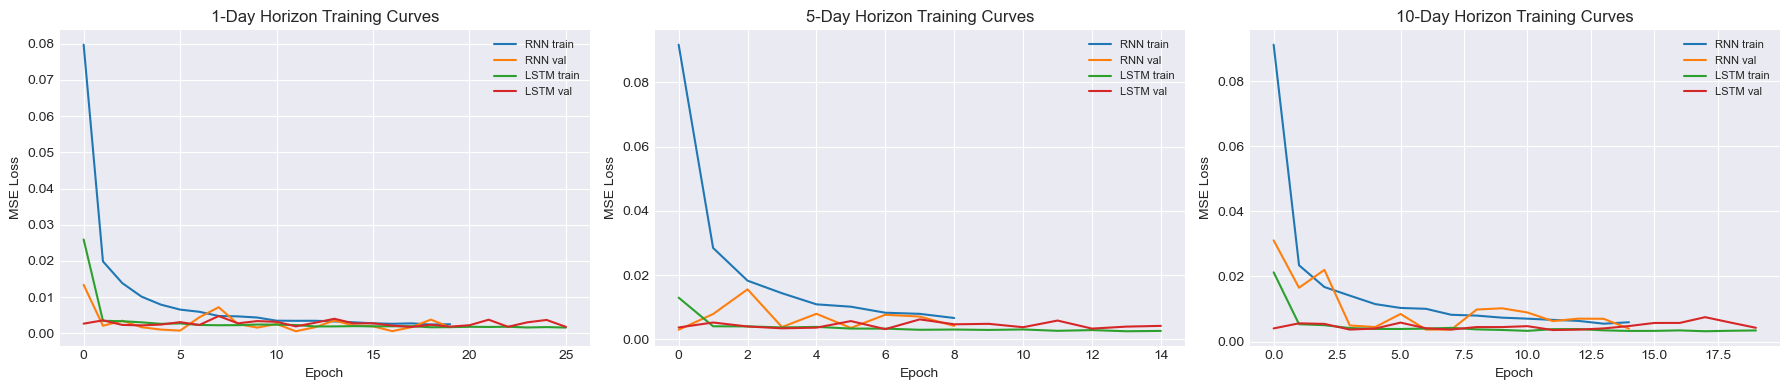

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18,4))
for ax, h in zip(axes, HORIZONS):
    ax.plot(histories[f"SimpleRNN_h{h}"]["loss"], label="RNN train")
    ax.plot(histories[f"SimpleRNN_h{h}"]["val_loss"], label="RNN val")
    ax.plot(histories[f"LSTM_h{h}"]["loss"], label="LSTM train")
    ax.plot(histories[f"LSTM_h{h}"]["val_loss"], label="LSTM val")
    ax.set_title(f"{h}-Day Horizon Training Curves")
    ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


## Section 12: Evaluation — MSE / RMSE / MAE per model per horizon

In [25]:
eval_rows = []
predictions_store = {}

for h in HORIZONS:
    Xte, yte = datasets[h]['X_test'], datasets[h]['y_test']
    y_actual = scaler.inverse_transform(yte.reshape(-1,1))

    for arch in ["SimpleRNN", "LSTM"]:
        key = f"{arch}_h{h}"
        model = load_model(results[key]['model_path'])
        pred_scaled = model.predict(Xte, verbose=0)
        pred = scaler.inverse_transform(pred_scaled)

        mse = mean_squared_error(y_actual, pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_actual, pred)

        eval_rows.append({"Model": arch, "Horizon (days)": h, "MSE": mse, "RMSE": rmse, "MAE": mae})
        predictions_store[key] = dict(actual=y_actual, pred=pred)

comparison = pd.DataFrame(eval_rows).sort_values(["Horizon (days)", "Model"]).reset_index(drop=True)
comparison


,Model,Horizon (days),MSE,RMSE,MAE
0,LSTM,1,699.299354,26.444269,17.367317
1,SimpleRNN,1,399.132704,19.978306,12.521720
2,LSTM,5,1419.734732,37.679367,25.313882
3,SimpleRNN,5,1858.120902,43.105927,29.121729
4,LSTM,10,2021.555572,44.961712,31.286584
5,SimpleRNN,10,2459.547529,49.593826,32.892623


In [26]:
## Section 13: Actual vs Predicted — visualizations per horizon

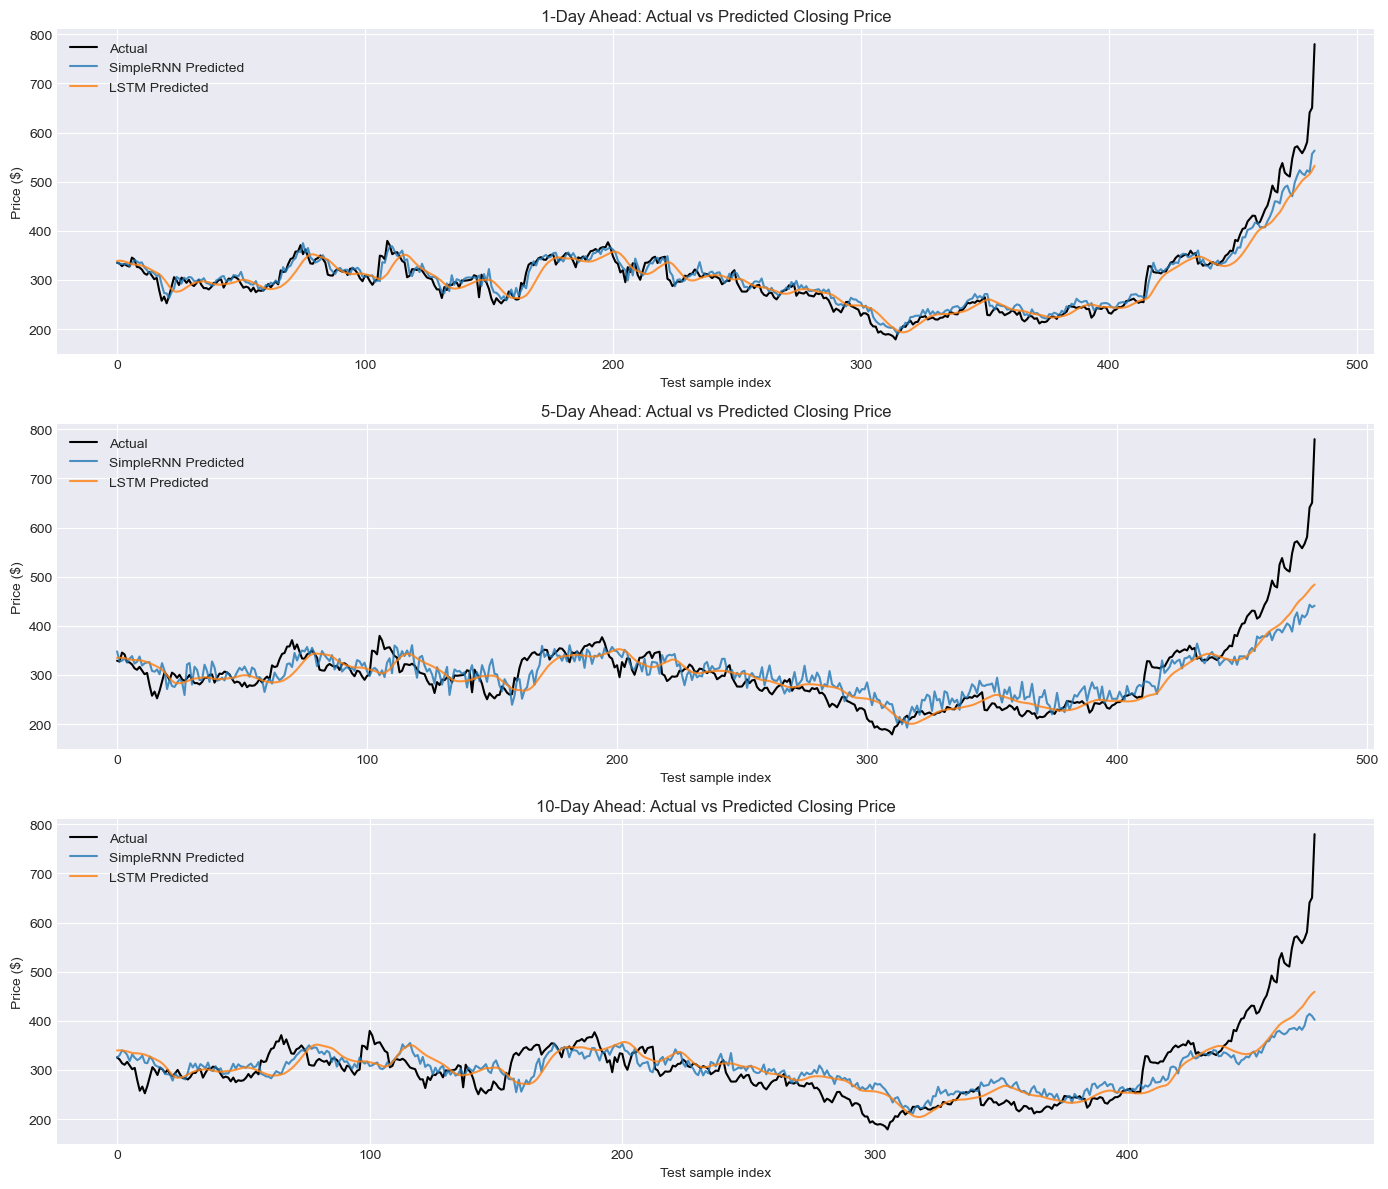

In [27]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
for ax, h in zip(axes, HORIZONS):
    ax.plot(predictions_store[f"SimpleRNN_h{h}"]["actual"], label="Actual", color="black", linewidth=1.5)
    ax.plot(predictions_store[f"SimpleRNN_h{h}"]["pred"], label="SimpleRNN Predicted", alpha=0.8)
    ax.plot(predictions_store[f"LSTM_h{h}"]["pred"], label="LSTM Predicted", alpha=0.8)
    ax.set_title(f"{h}-Day Ahead: Actual vs Predicted Closing Price")
    ax.set_xlabel("Test sample index"); ax.set_ylabel("Price ($)"); ax.legend()
plt.tight_layout(); plt.show()


## Section 14: Hyperparameter Tuning with GridSearchCV

In [28]:
import sys
print(sys.executable)

C:\ProgramData\anaconda3\python.exe


In [29]:
from scikeras.wrappers import KerasRegressor

print("SciKeras OK")

SciKeras OK


In [30]:
from scikeras.wrappers import KerasRegressor
from sklearn.model_selection import GridSearchCV

def build_lstm_for_grid(units=64, dropout=0.2, learning_rate=0.001):
    return build_lstm(WINDOW, units=units, dropout=dropout, learning_rate=learning_rate)

Xtr1, ytr1 = datasets[1]['X_train'], datasets[1]['y_train']

reg = KerasRegressor(model=build_lstm_for_grid, verbose=0, epochs=8, batch_size=32)

param_grid = {
    "model__units": [32, 64],
    "model__dropout": [0.2, 0.3],
    "model__learning_rate": [0.001, 0.005],
}

grid = GridSearchCV(estimator=reg, param_grid=param_grid,
                     scoring="neg_mean_squared_error", cv=2, n_jobs=1)
grid_result = grid.fit(Xtr1, ytr1)

print("Best params:", grid_result.best_params_)
print("Best CV score (neg MSE):", grid_result.best_score_)


Best params: {'model__dropout': 0.2, 'model__learning_rate': 0.005, 'model__units': 64}
Best CV score (neg MSE): -0.0014754740525216624


In [31]:
grid_results_df = pd.DataFrame(grid_result.cv_results_)[
    ["param_model__units", "param_model__dropout", "param_model__learning_rate", "mean_test_score", "rank_test_score"]
].sort_values("rank_test_score")
grid_results_df.columns = ["Units", "Dropout", "Learning Rate", "Mean CV Score (neg MSE)", "Rank"]
grid_results_df


,Units,Dropout,Learning Rate,Mean CV Score (neg MSE),Rank
3,64,0.2,0.005,-0.001475,1
1,64,0.2,0.001,-0.001511,2
7,64,0.3,0.005,-0.002110,3
5,64,0.3,0.001,-0.002461,4
2,32,0.2,0.005,-0.002624,5
0,32,0.2,0.001,-0.002676,6
6,32,0.3,0.005,-0.005136,7
4,32,0.3,0.001,-0.005480,8


In [32]:
best_params = {k.replace("model__",""): v for k, v in grid_result.best_params_.items()}
print("Retraining final tuned LSTM (1-day horizon) with:", best_params)

tuned_model = build_lstm(WINDOW, **best_params)
cbs = [EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
       ModelCheckpoint("best_LSTM_h1_tuned.keras", monitor="val_loss", save_best_only=True)]
tuned_hist = tuned_model.fit(Xtr1, ytr1, validation_split=0.1, epochs=50,
                              batch_size=32, callbacks=cbs, verbose=0)

Xte1, yte1 = datasets[1]['X_test'], datasets[1]['y_test']
y_actual1 = scaler.inverse_transform(yte1.reshape(-1,1))
pred_tuned = scaler.inverse_transform(tuned_model.predict(Xte1, verbose=0))

tuned_mse = mean_squared_error(y_actual1, pred_tuned)
tuned_rmse = np.sqrt(tuned_mse)
print(f"Tuned LSTM (1-day) -> MSE: {tuned_mse:.4f}, RMSE: {tuned_rmse:.4f}")

baseline_row = comparison[(comparison.Model=="LSTM") & (comparison["Horizon (days)"]==1)]
print("\nBaseline (untuned) LSTM 1-day RMSE:", baseline_row['RMSE'].values[0])


Retraining final tuned LSTM (1-day horizon) with: {'dropout': 0.2, 'learning_rate': 0.005, 'units': 64}
Tuned LSTM (1-day) -> MSE: 289.7907, RMSE: 17.0232

Baseline (untuned) LSTM 1-day RMSE: 26.444268839534175


## Section 15: Model Comparison

In [33]:
comparison_sorted = comparison.pivot(index="Horizon (days)", columns="Model", values="RMSE")
comparison_sorted


Model,LSTM,SimpleRNN
Horizon (days),,
1,26.444269,19.978306
5,37.679367,43.105927
10,44.961712,49.593826


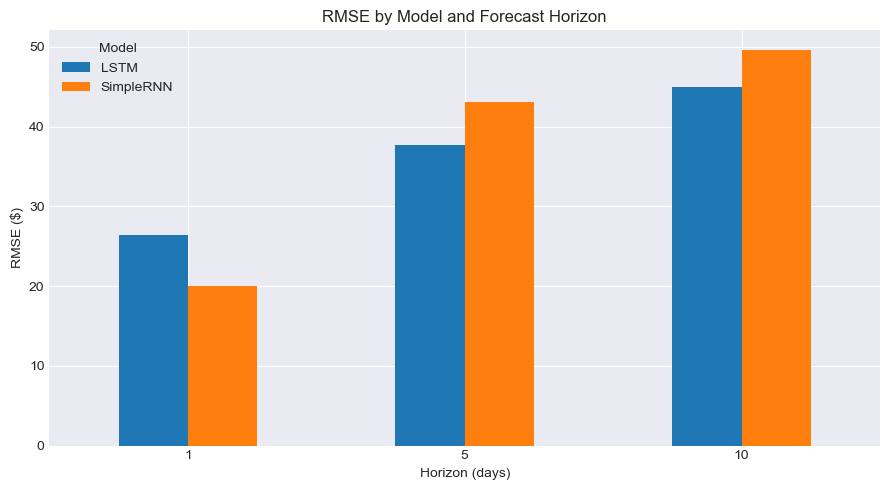

In [34]:
fig, ax = plt.subplots(figsize=(9,5))
comparison_sorted.plot(kind="bar", ax=ax)
ax.set_title("RMSE by Model and Forecast Horizon")
ax.set_ylabel("RMSE ($)")
plt.xticks(rotation=0)
plt.tight_layout(); plt.show()


In [35]:
comparison

,Model,Horizon (days),MSE,RMSE,MAE
0,LSTM,1,699.299354,26.444269,17.367317
1,SimpleRNN,1,399.132704,19.978306,12.521720
2,LSTM,5,1419.734732,37.679367,25.313882
3,SimpleRNN,5,1858.120902,43.105927,29.121729
4,LSTM,10,2021.555572,44.961712,31.286584
5,SimpleRNN,10,2459.547529,49.593826,32.892623


## Section 16: 1-Day, 5-Day, 10-Day Forward Forecast (beyond the dataset)

In [36]:
best_lstm_h1 = load_model(results["LSTM_h1"]["model_path"])

last_60 = full_scaled[-WINDOW:].reshape(1, WINDOW, 1)
future_scaled = []
cur = last_60.copy()
for i in range(10):
    p = best_lstm_h1.predict(cur, verbose=0)
    future_scaled.append(p[0,0])
    cur = np.append(cur[:,1:,:], p.reshape(1,1,1), axis=1)

future_prices = scaler.inverse_transform(np.array(future_scaled).reshape(-1,1))
for i, price in enumerate(future_prices, start=1):
    tag = " (matches 1-day model)" if i==1 else " (5-day)" if i==5 else " (10-day)" if i==10 else ""
    print(f"Day {i}: ${price[0]:.2f}{tag}")


Day 1: $550.88 (matches 1-day model)
Day 2: $556.76
Day 3: $557.35
Day 4: $554.11
Day 5: $548.20 (5-day)
Day 6: $540.47
Day 7: $531.57
Day 8: $521.98
Day 9: $512.07
Day 10: $502.08 (10-day)


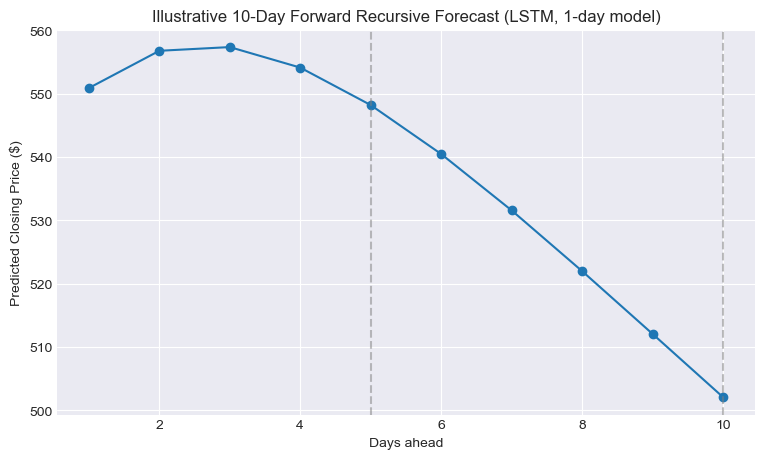

In [37]:
plt.figure(figsize=(9,5))
plt.plot(range(1,11), future_prices, marker="o")
plt.axvline(5, color="gray", linestyle="--", alpha=0.5)
plt.axvline(10, color="gray", linestyle="--", alpha=0.5)
plt.title("Illustrative 10-Day Forward Recursive Forecast (LSTM, 1-day model)")
plt.xlabel("Days ahead"); plt.ylabel("Predicted Closing Price ($)")
plt.grid(True); plt.show()


## Section 17: Insights & Conclusion

## Data & preprocessing

No missing values in the raw TSLA.csv; a defensible time-series-safe strategy (forward-fill + interpolation) was demonstrated for how gaps would be handled.
Scaler was fit strictly on training data to avoid leakage; validation during training was carved out of the training split only, keeping the test set genuinely held out.

## Model performance

RMSE generally increases with horizon (1-day easiest, 10-day hardest) — expected, since uncertainty compounds further into the future.
See the comparison table/chart in Section 15 for which architecture (SimpleRNN vs LSTM) performed better at each horizon on this dataset.

## Hyperparameter tuning

GridSearchCV over units/dropout/learning-rate identified the configuration in Section 14; the retrained tuned LSTM's RMSE is compared against the untuned baseline.

## Limitations

Purely price-history-based sequence models cannot react to news, earnings surprises, or macro shocks (e.g., the Jan–Feb 2020 price spike visible in the EDA).
Recursive multi-step forecasting (Section 16) compounds prediction error at each step.

## Possible improvements

Add exogenous features (news sentiment, trading volume trends, macro indicators like interest rates) as additional input channels.
Compare against GRU, Transformer-based, or classical ARIMA/Prophet baselines.
Wider/deeper GridSearchCV, and tuning window size / batch size as additional axes.